# Notebook 3: Ideology Analysis — Generalized Euclidean Distance

Measures ideological polarization in the event-event networks using the Generalized Euclidean (GE) measure (Coscia, 2020; Hohmann et al., 2023), and evaluates statistical significance via a shuffle-based null model.

**Inputs** from `../data/processed/`:
- `backboned_graph_{key}.pkl` — noise-corrected event-event LCC graphs
- `filtered_events_{key}.pkl` — event DataFrames (LCC only)
- `filtered_users_{key}.pkl` — user DataFrames (connected to LCC events)

**Outputs** (displayed inline):
- Table 7.1 — ideology SD statistics
- Table D.2 — GE distance results
- Table D.3 — event network basic statistics
- Figure 7.1 — GE distance over time
- Figure 7.2 — GE null model results

**Pipeline**
1. Compute GE distance for each event-event network
2. Run 10-shuffle null model per network
3. Compute Table 7.1 ideology SD statistics
4. Compute Table D.3 event network statistics
5. Plot Figures 7.1 and 7.2

In [1]:
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse.csgraph import laplacian

sns.set_theme(rc={"lines.linewidth": 2}, font_scale=1.5)
sns.set_style("whitegrid")

DATA_DIR = Path('../data/processed')

KEYS = [
    'small_2013-2014', 'small_2014-2015', 'small_2015-2016', 'small_2016-2017',
    'medium_2013-2014', 'medium_2014-2015', 'medium_2015-2016', 'medium_2016-2017',
]

YEARS          = np.array([2014, 2015, 2016, 2017])
ELECTION_YEAR  = 2015.5
SHADING_RANGES = [2013.5, 2014.5, 2015.5, 2016.5, 2017.5]
SHADES         = ["#D1F2EB", "#FCF3CB"]

## 1. Load Inputs

In [2]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

backboned_graphs  = {k: load_pkl(DATA_DIR / f'backboned_graph_{k}.pkl') for k in KEYS}
filtered_events   = {k: pd.read_pickle(DATA_DIR / f'filtered_events_{k}.pkl')  for k in KEYS}
filtered_users    = {k: pd.read_pickle(DATA_DIR / f'filtered_users_{k}.pkl')   for k in KEYS}

print("Loaded backboned graphs, filtered events, and filtered users for all 8 datasets.")
for k in KEYS:
    G = backboned_graphs[k]
    print(f"  {k}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loaded backboned graphs, filtered events, and filtered users for all 8 datasets.
  small_2013-2014: 8,210 nodes, 120,395 edges
  small_2014-2015: 9,603 nodes, 161,359 edges
  small_2015-2016: 13,838 nodes, 255,862 edges
  small_2016-2017: 17,459 nodes, 346,228 edges
  medium_2013-2014: 4,709 nodes, 372,565 edges
  medium_2014-2015: 5,779 nodes, 542,037 edges
  medium_2015-2016: 7,764 nodes, 812,899 edges
  medium_2016-2017: 7,573 nodes, 691,767 edges


## 2. Generalized Euclidean Distance

The GE measure (Coscia, 2020) quantifies the structural cost of transporting opinion mass from one ideological group to another across the network. Each event receives an opinion value from its weighted ideology score:

- **o⁺**: right-leaning component — `max(ideology, 0)`  
- **o⁻**: left-leaning component — `max(−ideology, 0)`

The GE distance is:
$$\text{GE} = \sqrt{(\mathbf{v}^+ - \mathbf{v}^-)^\top \mathbf{L}^+ (\mathbf{v}^+ - \mathbf{v}^-)}$$

where **L**⁺ is the Moore-Penrose pseudoinverse of the graph Laplacian.

In [3]:
def compute_ge(G):
    """Compute GE distance for a weighted graph with ideology node attributes.

    Nodes missing or with NaN ideology are treated as neutral (contribute 0
    to both opinion vectors and cancel out in the difference).
    """
    A = nx.adjacency_matrix(G, weight='weight').todense().astype(float)
    L = np.linalg.pinv(laplacian(A, normed=False))

    nodes = list(G.nodes())
    ideology = {
        n: G.nodes[n].get('weighted_ideology_min_max', np.nan)
        for n in nodes
    }

    v_plus  = np.array([max(ideology[n], 0)         if pd.notna(ideology[n]) else 0.0 for n in nodes])
    v_minus = np.array([abs(ideology[n]) if ideology[n] < 0 else 0.0
                        if pd.notna(ideology[n]) else 0.0 for n in nodes])

    diff = v_plus - v_minus
    return float(np.sqrt(diff.T @ L @ diff))


ge_results = {}

for key, G in backboned_graphs.items():
    ge = compute_ge(G)
    ge_results[key] = ge
    print(f"{key}: GE = {ge:.4f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/tmp/claude-501/ipykernel_81367/3240956658.py:21: RuntimeWarning: divide by zero encountered in matmul
  return float(np.sqrt(diff.T @ L @ diff))
/tmp/claude-501/ipykernel_81367/3240956658.py:21: RuntimeWarning: overflow encountered in matmul
  return float(np.sqrt(diff.T @ L @ diff))
/tmp/claude-501/ipykernel_81367/3240956658.py:21: RuntimeWarning: invalid value encountered in matmul
  return float(np.sqrt(diff.T @ L @ diff

small_2013-2014: GE = 7.8695


small_2014-2015: GE = 8.1389


small_2015-2016: GE = 10.5686


small_2016-2017: GE = 9.3653


medium_2013-2014: GE = 1.0556


medium_2014-2015: GE = 1.2344


medium_2015-2016: GE = 1.1745


medium_2016-2017: GE = 1.1416


## 3. Null Model

Ideology labels are shuffled randomly across events 10 times per graph. The resulting distribution shows the expected GE distance under random assignment, providing a baseline for assessing the degree of ideological clustering.

In [4]:
N_SHUFFLES = 10
ge_null    = {}

for key, G in backboned_graphs.items():
    print(f"{key}...")

    A = nx.adjacency_matrix(G, weight='weight').todense().astype(float)
    L = np.linalg.pinv(laplacian(A, normed=False))

    nodes    = list(G.nodes())
    ideology = {
        n: G.nodes[n].get('weighted_ideology_min_max', np.nan)
        for n in nodes
        if pd.notna(G.nodes[n].get('weighted_ideology_min_max', np.nan))
    }

    values   = list(ideology.values())
    node_keys = list(ideology.keys())
    shuffled_ge = []

    for _ in range(N_SHUFFLES):
        random.shuffle(values)
        shuffled = dict(zip(node_keys, values))

        v_plus  = np.array([max(shuffled.get(n, 0), 0)                              for n in nodes])
        v_minus = np.array([abs(shuffled[n]) if n in shuffled and shuffled[n] < 0 else 0.0 for n in nodes])

        diff = v_plus - v_minus
        shuffled_ge.append(float(np.sqrt(diff.T @ L @ diff)))

    ge_null[key] = shuffled_ge
    print(f"  Mean ± SD: {np.mean(shuffled_ge):.4f} ± {np.std(shuffled_ge):.4f}")

small_2013-2014...


/tmp/claude-501/ipykernel_81367/2057116162.py:29: RuntimeWarning: divide by zero encountered in matmul
  shuffled_ge.append(float(np.sqrt(diff.T @ L @ diff)))
/tmp/claude-501/ipykernel_81367/2057116162.py:29: RuntimeWarning: overflow encountered in matmul
  shuffled_ge.append(float(np.sqrt(diff.T @ L @ diff)))
/tmp/claude-501/ipykernel_81367/2057116162.py:29: RuntimeWarning: invalid value encountered in matmul
  shuffled_ge.append(float(np.sqrt(diff.T @ L @ diff)))


  Mean ± SD: 4.9932 ± 0.1032
small_2014-2015...


  Mean ± SD: 4.9017 ± 0.1381
small_2015-2016...


  Mean ± SD: 5.4180 ± 0.0778
small_2016-2017...


  Mean ± SD: 5.8618 ± 0.0726
medium_2013-2014...


  Mean ± SD: 0.6835 ± 0.0308
medium_2014-2015...


  Mean ± SD: 0.7406 ± 0.0453
medium_2015-2016...


  Mean ± SD: 0.7589 ± 0.0099
medium_2016-2017...


  Mean ± SD: 0.7563 ± 0.0410


## 4. Table 7.1 — Ideology SD Statistics

Two complementary measures of ideological spread:
- **Inter-event SD**: standard deviation of weighted ideology scores *across* events — how spread out the events are ideologically.
- **Intra-event SD**: for each event, compute the SD of its political attendees' ideology scores; report the average across all events — how mixed each individual event is.

In [5]:
def inter_event_sd(events_df):
    return events_df['weighted_ideology_min_max'].dropna().std()


def avg_intra_event_sd(events_df, users_df):
    user_ideology = users_df.set_index('hashed_id')['normalized_min_max'].dropna().to_dict()

    event_sds = []
    for _, ev in events_df.iterrows():
        scores = [
            user_ideology[uid]
            for uid in ev['political_attendees']
            if uid in user_ideology
        ]
        if len(scores) > 1:
            event_sds.append(np.std(scores, ddof=0))

    return np.mean(event_sds) if event_sds else np.nan


table_7_1_rows = []
for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
    row = {'Time Period': period}
    for size in ['small', 'medium']:
        key = f'{size}_{period}'
        row[f'Inter-event SD ({size})'] = round(inter_event_sd(filtered_events[key]), 3)
        row[f'Avg intra-event SD ({size})'] = round(
            avg_intra_event_sd(filtered_events[key], filtered_users[key]), 3
        )
    table_7_1_rows.append(row)

table_7_1 = pd.DataFrame(table_7_1_rows).set_index('Time Period')
print("Table 7.1:")
print(table_7_1.to_string())

Table 7.1:
             Inter-event SD (small)  Avg intra-event SD (small)  Inter-event SD (medium)  Avg intra-event SD (medium)
Time Period                                                                                                          
2013-2014                     0.160                       0.290                    0.094                        0.387
2014-2015                     0.159                       0.292                    0.102                        0.385
2015-2016                     0.154                       0.300                    0.099                        0.385
2016-2017                     0.154                       0.295                    0.093                        0.393


## 5. Table D.2 — GE Distance Results

In [6]:
table_d2_rows = []
for size in ['Small', 'Medium']:
    for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
        key = f'{size.lower()}_{period}'
        table_d2_rows.append({
            'Event Size': size,
            'Time Period': period,
            'GE Distance': round(ge_results[key], 2),
        })

table_d2 = pd.DataFrame(table_d2_rows)
print("Table D.2 — GE Distance Results:")
print(table_d2.to_string(index=False))

Table D.2 — GE Distance Results:
Event Size Time Period  GE Distance
     Small   2013-2014         7.87
     Small   2014-2015         8.14
     Small   2015-2016        10.57
     Small   2016-2017         9.37
    Medium   2013-2014         1.06
    Medium   2014-2015         1.23
    Medium   2015-2016         1.17
    Medium   2016-2017         1.14


## 6. Table D.3 — Event Network Basic Statistics

Standard network measures for the event-event LCC graphs. Average shortest path length and diameter are approximated by sampling 1,000 source nodes.

## Appendix C — Network Construction Statistics

### Table C.2 — User Counts by Ideological Orientation
### Table C.3 — Event-Level Ideology Data

In [7]:

PERIODS_ORDER = ['2013-2014', '2014-2015', '2015-2016', '2016-2017']

# ── Table C.2: User counts by ideological orientation ─────────────────────────
c2_rows = []
for size in ['Small', 'Medium']:
    for period in PERIODS_ORDER:
        key  = f'{size.lower()}_{period}'
        u    = filtered_users[key]
        pol  = int(u['political'].sum())
        r    = int((u['l_r_min_max'] == 'R').sum())
        l    = int((u['l_r_min_max'] == 'L').sum())
        c2_rows.append({
            'Event Size':            size,
            'Time Period':           period,
            'Total Political Users': pol,
            'Total R Users':         r,
            'Total L Users':         l,
            '% R Users':             round(r / pol * 100, 2) if pol > 0 else 0,
            '% L Users':             round(l / pol * 100, 2) if pol > 0 else 0,
        })

table_c2 = pd.DataFrame(c2_rows)
print('Table C.2 — User Counts by Ideological Orientation:')
print(table_c2.to_string(index=False))

# ── Table C.3: Event-level ideology data ──────────────────────────────────────
c3_rows = []
for size in ['Small', 'Medium']:
    for period in PERIODS_ORDER:
        key  = f'{size.lower()}_{period}'
        ev   = filtered_events[key]
        n    = len(ev)
        avg  = round(ev['weighted_ideology_min_max'].mean(), 2)
        l_n  = int((ev['weighted_ideology_min_max'] < 0).sum())
        r_n  = int((ev['weighted_ideology_min_max'] > 0).sum())
        neu  = int((ev['weighted_ideology_min_max'] == 0).sum())
        c3_rows.append({
            'Event Size':                size,
            'Time Period':               period,
            'Avg Weighted Ideology':     avg,
            'Total Events':              n,
            'L Event Count':             l_n,
            'R Event Count':             r_n,
            'Neutral Event Count':       neu,
            '% L Events':               round(l_n / n * 100, 2),
            '% R Events':               round(r_n / n * 100, 2),
            '% Neutral Events':         round(neu / n * 100, 2),
        })

table_c3 = pd.DataFrame(c3_rows)
print('\nTable C.3 — Event-Level Ideology Data:')
print(table_c3.to_string(index=False))


Table C.2 — User Counts by Ideological Orientation:
Event Size Time Period  Total Political Users  Total R Users  Total L Users  % R Users  % L Users
     Small   2013-2014                  14646           2891          11755      19.74      80.26
     Small   2014-2015                  16965           3491          13474      20.58      79.42
     Small   2015-2016                  22774           4700          18074      20.64      79.36
     Small   2016-2017                  25703           5319          20384      20.69      79.31
    Medium   2013-2014                  25370           5513          19857      21.73      78.27
    Medium   2014-2015                  30833           6815          24018      22.10      77.90
    Medium   2015-2016                  38100           8563          29537      22.48      77.52
    Medium   2016-2017                  37408           8376          29032      22.39      77.61

Table C.3 — Event-Level Ideology Data:
Event Size Time Period  Av

In [8]:
def approx_path_stats(G, n_sample=1000, seed=42):
    """Estimate average shortest path length and diameter by BFS from sampled nodes."""
    rng       = random.Random(seed)
    nodes     = list(G.nodes())
    sample    = rng.sample(nodes, min(n_sample, len(nodes)))
    all_dists = []
    for src in sample:
        dists = nx.single_source_shortest_path_length(G, src)
        all_dists.extend(d for d in dists.values() if d > 0)
    return round(np.mean(all_dists), 2), max(all_dists)


def event_network_stats(G):
    clustering    = round(nx.average_clustering(G), 2)
    density       = round(nx.density(G), 4)
    assortativity = round(nx.degree_assortativity_coefficient(G), 2)

    communities   = nx.community.louvain_communities(G, seed=42)
    modularity    = round(nx.community.modularity(G, communities), 2)

    avg_path, diameter = approx_path_stats(G)

    return clustering, density, assortativity, modularity, avg_path, diameter


# Load event-event LCC graphs (needed for stats — backboned has same topology)
event_graphs = {k: load_pkl(DATA_DIR / f'event_graph_{k}.pkl') for k in KEYS}

table_d3_rows = []
for size in ['Small', 'Medium']:
    for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
        key = f'{size.lower()}_{period}'
        G   = event_graphs[key]
        print(f"{key}...")
        cc, dens, assort, mod, avgp, diam = event_network_stats(G)
        table_d3_rows.append({
            'Event Size': size, 'Time Period': period,
            'Events': G.number_of_nodes(), 'Edges': G.number_of_edges(),
            'Clustering Coeff': cc, 'Density': dens,
            'Degree Assortativity': assort, 'Modularity': mod,
            'Avg Shortest Path (approx)': avgp, 'Diameter (approx)': diam,
        })

table_d3 = pd.DataFrame(table_d3_rows)
print("\nTable D.3 — Event Networks LCC Basic Statistics:")
print(table_d3.to_string(index=False))

small_2013-2014...


small_2014-2015...


small_2015-2016...


small_2016-2017...


medium_2013-2014...


medium_2014-2015...


medium_2015-2016...


medium_2016-2017...



Table D.3 — Event Networks LCC Basic Statistics:
Event Size Time Period  Events  Edges  Clustering Coeff  Density  Degree Assortativity  Modularity  Avg Shortest Path (approx)  Diameter (approx)
     Small   2013-2014    8210 120395              0.47   0.0036                  0.43        0.76                        3.67                 11
     Small   2014-2015    9603 161359              0.46   0.0035                  0.37        0.75                        3.56                 10
     Small   2015-2016   13838 255862              0.42   0.0027                  0.34        0.69                        3.49                  9
     Small   2016-2017   17459 346228              0.41   0.0023                  0.43        0.67                        3.47                 10
    Medium   2013-2014    4709 372565              0.24   0.0336                  0.28        0.49                        2.23                  6
    Medium   2014-2015    5779 542037              0.22   0.0325          

## 7. Figure 7.1 — GE Distance Over Time

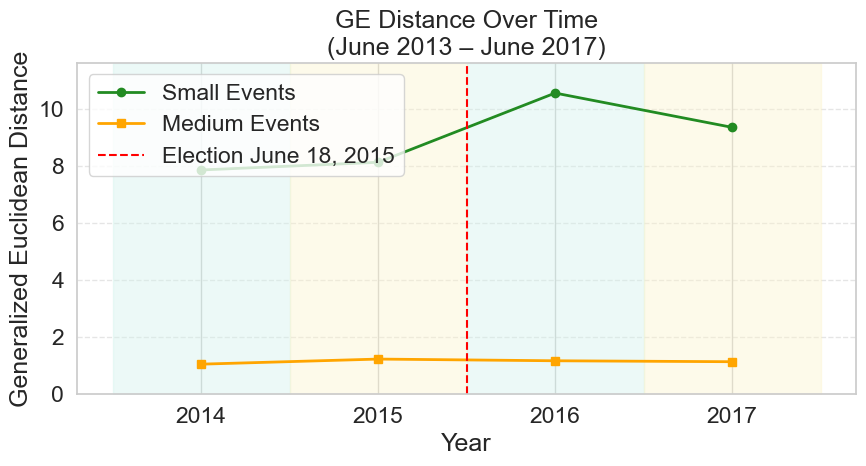

In [9]:
values_small  = [ge_results[f'small_{y-1}-{y}']  for y in YEARS]
values_medium = [ge_results[f'medium_{y-1}-{y}'] for y in YEARS]

y_max = max(values_small + values_medium) * 1.1

fig, ax = plt.subplots(figsize=(9, 5))

for i in range(len(SHADING_RANGES) - 1):
    ax.fill_betweenx([0, y_max], SHADING_RANGES[i], SHADING_RANGES[i+1],
                     color=SHADES[i % 2], alpha=0.4)

ax.plot(YEARS, values_small,  marker='o', linestyle='-',  label='Small Events',  color='forestgreen')
ax.plot(YEARS, values_medium, marker='s', linestyle='-',  label='Medium Events', color='orange')
ax.axvline(x=ELECTION_YEAR, color='red', linestyle='--', linewidth=1.5, label='Election June 18, 2015')

ax.set_xticks(YEARS)
ax.set_xlabel('Year')
ax.set_ylabel('Generalized Euclidean Distance')
ax.set_title('GE Distance Over Time\n(June 2013 – June 2017)')
ax.set_ylim(0, y_max)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_7_1_ge_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Figure 7.2 — GE Null Model Results

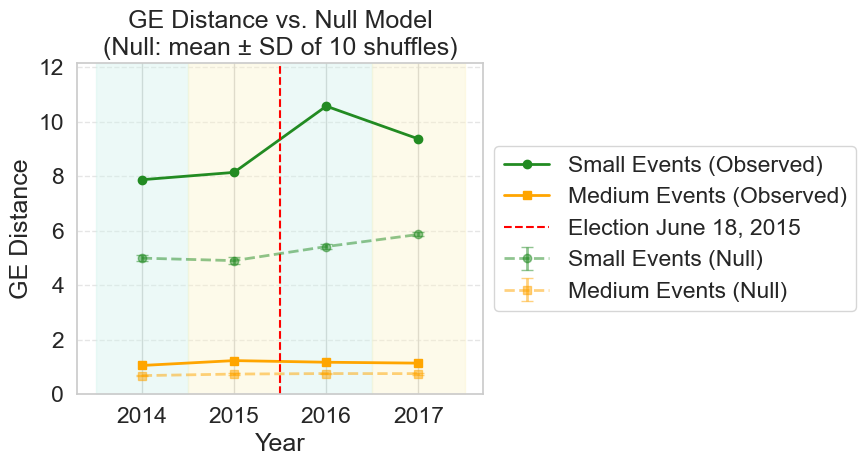

In [10]:
def null_stats(size_label):
    means, stds = [], []
    for y in YEARS:
        vals = ge_null.get(f'{size_label}_{y-1}-{y}', [np.nan] * N_SHUFFLES)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    return np.array(means), np.array(stds)

mean_s, std_s = null_stats('small')
mean_m, std_m = null_stats('medium')

# Combine observed and null for shared y-axis
all_vals = list(values_small) + list(values_medium) + list(mean_s + std_s) + list(mean_m + std_m)
y_max    = max(v for v in all_vals if not np.isnan(v)) * 1.15

fig, ax = plt.subplots(figsize=(9, 5))

for i in range(len(SHADING_RANGES) - 1):
    ax.fill_betweenx([0, y_max], SHADING_RANGES[i], SHADING_RANGES[i+1],
                     color=SHADES[i % 2], alpha=0.4)

ax.plot(YEARS, values_small,  marker='o', linestyle='-',  color='forestgreen', label='Small Events (Observed)')
ax.plot(YEARS, values_medium, marker='s', linestyle='-',  color='orange',      label='Medium Events (Observed)')

ax.errorbar(YEARS, mean_s, yerr=std_s, fmt='o--', color='forestgreen',
            alpha=0.5, capsize=4, label='Small Events (Null)')
ax.errorbar(YEARS, mean_m, yerr=std_m, fmt='s--', color='orange',
            alpha=0.5, capsize=4, label='Medium Events (Null)')

ax.axvline(x=ELECTION_YEAR, color='red', linestyle='--', linewidth=1.5, label='Election June 18, 2015')

ax.set_xticks(YEARS)
ax.set_xlabel('Year')
ax.set_ylabel('GE Distance')
ax.set_title('GE Distance vs. Null Model\n(Null: mean ± SD of 10 shuffles)')
ax.set_ylim(0, y_max)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_7_2_ge_null_model.png', dpi=150, bbox_inches='tight')
plt.show()